# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python) 

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [1]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency 


In [2]:
# cargar archivos
orders = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')

In [3]:
# explorar datasets
orders.info()
orders.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB


,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28


In [4]:
catalog.info()
catalog.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes


,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"


In [5]:
marketing.info()
marketing.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB


,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40


---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas 

---

In [6]:
#converitir a date time en orders

orders['fecha_hora_pedido'] = pd.to_datetime(orders['fecha_hora_pedido'], errors="coerce")



#validar tipo de dato
print(orders['fecha_hora_pedido'].dtype)



datetime64[ns]


In [7]:
fecha_min = orders['fecha_hora_pedido'].min()
fecha_max = orders['fecha_hora_pedido'].max()

print(f"Fecha mínima: {fecha_min}")
print(f"Fecha máxima: {fecha_max}")

Fecha mínima: 2025-01-01 00:00:00
Fecha máxima: 2025-06-30 00:00:00


In [8]:
# revisar valores numericos en orders


orders[['cantidad', 'precio_unitario', 'monto_descuento', 'monto_total']].describe()

,cantidad,precio_unitario,monto_descuento,monto_total
count,25050.000000,25050.000000,25050.000000,2.510000e+04
mean,7.092735,259.305549,4.500798,2.072680e+03
std,296.277003,138.726461,5.223010,9.894995e+04
min,-2.000000,20.030000,0.000000,-4.926500e+02
25%,1.000000,138.377500,0.000000,1.805075e+02
50%,2.000000,258.715000,0.000000,3.417500e+02
75%,2.000000,380.332500,10.000000,5.185800e+02
max,20000.000000,499.960000,15.000000,8.840200e+06


In [9]:
# total de valores faltantes en orders 
orders.isna().sum()

id_pedido               0
id_usuario              0
fecha_hora_pedido       0
pais                  300
dispositivo            20
fuente_referencia      30
nombre_producto        30
categoria_producto     80
cantidad               50
precio_unitario        50
monto_descuento        50
monto_total             0
dtype: int64

In [10]:
# revisar el total de valores faltantes en orders

orders.isna().sum().sum()

610

In [11]:
#Limpieza de valores nulos y negativos en orders

# 1. Eliminar filas con valores nulos en la columnas numericas clave
orders = orders.dropna(subset=['cantidad','precio_unitario','monto_descuento']).reset_index(drop=True)

# 2. Eliminar registros con ceros o negativos en cantidad y precio_unitario
orders = orders[(orders['cantidad'] > 0) & (orders['precio_unitario'] > 0)]

# 3. Recalcular 'monto_total' para corregir los montos negativos e inconsistencias
orders['monto_total'] = (orders['cantidad'] * orders['precio_unitario']) - orders['monto_descuento']

# 4. Asegurar que 'cantidad' sea un número entero (int)
orders['cantidad'] = orders['cantidad'].astype(int)


# 5. Validacion
orders[['cantidad', 'precio_unitario', 'monto_descuento', 'monto_total']].describe()




,cantidad,precio_unitario,monto_descuento,monto_total
count,25046.000000,25046.000000,25046.000000,2.504600e+04
mean,7.094067,259.304400,4.500719,2.076331e+03
std,296.300643,138.715188,5.223232,9.905653e+04
min,1.000000,20.030000,0.000000,5.240000e+00
25%,1.000000,138.405000,0.000000,1.804025e+02
50%,2.000000,258.715000,0.000000,3.415600e+02
75%,2.000000,380.272500,10.000000,5.184450e+02
max,20000.000000,499.960000,15.000000,8.840200e+06


In [12]:
# validar el total de valores faltantes en orders en columnas numericas

orders.isna().sum()

id_pedido               0
id_usuario              0
fecha_hora_pedido       0
pais                  296
dispositivo            20
fuente_referencia      30
nombre_producto        30
categoria_producto     30
cantidad                0
precio_unitario         0
monto_descuento         0
monto_total             0
dtype: int64

In [13]:
#revisar duplicados

orders.duplicated().sum()

100

In [14]:
# Contar duplicados por id_pedido


duplicados_id = orders.duplicated(subset=['id_pedido']).sum()
print(f"Duplicados por id_pedido: {duplicados_id}")


Duplicados por id_pedido: 100


In [15]:
# Ver las filas que comparten el mismo id_pedido
orders[orders.duplicated(subset=['id_pedido'], keep=False)].sort_values(by='id_pedido').head(10)

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
24973,order_10082,user_690,2025-02-17,Argentina,desktop,social,Sneakers-Urban-42,Moda,2,221.34,0.0,442.68
10032,order_10082,user_690,2025-02-17,Argentina,desktop,social,Sneakers-Urban-42,Moda,2,221.34,0.0,442.68
24987,order_10709,user_6783,2025-02-16,Colombia,mobile,organic,Jacket-Winter-M,Moda,1,170.10,10.0,160.10
10659,order_10709,user_6783,2025-02-16,Colombia,mobile,organic,Jacket-Winter-M,Moda,1,170.10,10.0,160.10
25015,order_10829,user_7697,2025-01-23,Argentina,mobile,social,Phone-Pro-128GB,Electronica,2,115.54,0.0,231.08
10779,order_10829,user_7697,2025-01-23,Argentina,mobile,social,Phone-Pro-128GB,Electronica,2,115.54,0.0,231.08
10806,order_10856,user_1899,2025-03-18,Colombia,desktop,social,Laptop-Gaming-16GB,Electronica,1,72.53,0.0,72.53
24994,order_10856,user_1899,2025-03-18,Colombia,desktop,social,Laptop-Gaming-16GB,Electronica,1,72.53,0.0,72.53
11399,order_11449,user_1480,2025-03-21,Mexico,desktop,paid_search,Vacuum-Pro-Black,Hogar,1,60.55,5.0,55.55
25033,order_11449,user_1480,2025-03-21,Mexico,desktop,paid_search,Vacuum-Pro-Black,Hogar,1,60.55,5.0,55.55


In [16]:
# Eliminar filas duplicadas manteniendo únicamente la primera aparición

orders = orders.drop_duplicates(subset=['id_pedido'], keep='first')

#verificar que ya no existen id_pedido repetidos
print("Duplicados restantes:", orders.duplicated(subset=['id_pedido']).sum())

Duplicados restantes: 0


In [17]:
# con base en la descripcion estadistica de las columnas numericas, se revisan las transacciones con cantidades mayores a 100

orders[orders['cantidad'] > 100]

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
3471,order_3521,user_5812,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,10000,43.14,0.0,431400.0
3472,order_3522,user_3575,2025-03-29,Argentina,desktop,social,Laptop-Gaming-16GB,Electronica,10000,280.55,0.0,2805500.0
3536,order_3586,user_3380,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,10000,490.35,0.0,4903500.0
3593,order_3643,user_4440,2025-01-07,Colombia,desktop,social,Laptop-Gaming-16GB,Electronica,10000,238.15,0.0,2381500.0
3606,order_3656,user_884,2025-01-01,Argentina,mobile,organic,Laptop-Gaming-16GB,Electronica,20000,297.66,0.0,5953200.0
3618,order_3668,user_7270,2025-06-24,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,20000,348.31,0.0,6966200.0
3639,order_3689,user_6566,2025-06-16,mexico,desktop,paid_search,Laptop-Gaming-16GB,Electronica,10000,87.69,0.0,876900.0
3672,order_3722,user_4723,2025-05-09,Argentina,mobile,paid_search,Laptop-Gaming-16GB,Electronica,20000,442.01,0.0,8840200.0
3676,order_3726,user_2536,2025-02-12,Colombia,desktop,social,Laptop-Gaming-16GB,Electronica,20000,290.85,0.0,5817000.0
3698,order_3748,user_7096,2025-02-23,Mexico,desktop,organic,Laptop-Gaming-16GB,Electronica,10000,336.93,0.0,3369300.0


Se identifican outliers en la columna cantidad.
No hay certeza de que estos valores sean totalmente posibles para mantenerlos. 
Tampoco son valores imposibles para eliminarlos.
Por lo tanto se decide Winsorizar, ya que hay duda de errores de captura, pero no evidencia para eliminarlos.

In [18]:
# Calculo de percentil 1 
lower = orders['cantidad'].quantile(0.01)
lower


1.0

In [19]:
# Calculo de percentil 99
upper = orders['cantidad'].quantile(0.99)
upper

2.0

In [20]:
# Reemplazo valores

orders['cantidad_winsor'] = np.clip(orders['cantidad'], lower, upper)
orders[["cantidad", "cantidad_winsor"]].head()

,cantidad,cantidad_winsor
0,2,2
1,1,1
2,2,2
3,1,1
4,1,1


In [21]:
# Validacion 
orders[["cantidad", "cantidad_winsor"]].describe()

,cantidad,cantidad_winsor
count,24946.000000,24946.000000
mean,7.116452,1.505131
std,296.893743,0.499984
min,1.000000,1.000000
25%,1.000000,1.000000
50%,2.000000,2.000000
75%,2.000000,2.000000
max,20000.000000,2.000000


In [22]:
# Revisión estadística del precio unitario por producto

orders.groupby(['categoria_producto', 'nombre_producto'])['precio_unitario'].agg(
    ['min', 'mean', 'max', 'std']
)

min        mean     max         std
categoria_producto nombre_producto                                            
Electronica        Laptop-Gaming-16GB    20.24  261.359960  499.95  140.009266
                   Phone-Pro-128GB       20.08  259.533187  499.86  138.151559
                   Tablet-Standard-64GB  20.03  257.533126  499.89  138.637579
Hogar              Blender-XL-Red        20.06  259.157926  499.94  137.521504
                   Vacuum-Pro-Black      20.37  261.018463  499.96  139.276555
Moda               Jacket-Winter-M       20.06  259.818113  499.93  138.945514
                   Sneakers-Urban-42     20.11  257.232930  499.91  138.454683

Al auditar la columna precio_unitario, se identificó que todos los productos comparten un rango idéntico de 20 a 500 y una media cercana a 260. Esto evidencia que los precios provienen de una simulación sintética uniforme y no de un catálogo fijo de precios por producto.

In [23]:

# Revisar variables categoricas

col_cat = ['pais', 'dispositivo', 'fuente_referencia', 'nombre_producto', 'categoria_producto']

# Ver valores únicos de las columnas principales
for col in ['pais', 'dispositivo', 'fuente_referencia', 'categoria_producto']:
    if col in orders.columns:
        print(f"--- {col.upper()} ---")
        print(orders[col].unique())
        print()


--- PAIS ---
['Argentina' 'Mexico' 'Colombia' 'mexico' 'colombia' nan 'argentina']

--- DISPOSITIVO ---
['desktop' 'mobile' nan]

--- FUENTE_REFERENCIA ---
['organic' 'paid_search' 'social' nan]

--- CATEGORIA_PRODUCTO ---
['Moda' 'Electronica' 'Hogar' nan]



In [24]:
# Convertir a texto, eliminar espacios extra en extremos

for col in col_cat:
    if col in orders.columns:
        orders[col] = orders[col].astype(str).str.strip()

In [25]:
# Reemplazar 'nan' o nulos por 'Desconocido' o 'Sin información'

for col in col_cat:
    orders[col] = orders[col].replace({'nan': 'Desconocido', np.nan: 'Desconocido'})

In [26]:
# Corregir inconsistencias en nombres

reemplazos_pais = {
    'argentina': 'Argentina',
    'mexico': 'Mexico',
    'colombia': 'Colombia'
}

orders['pais'] = orders['pais'].replace(reemplazos_pais)

In [27]:
# Comprobar frecuencias de cada categoría

for col in col_cat:
    print(orders[col].value_counts(dropna=False))
    print()

Mexico         8327
Colombia       8289
Argentina      8034
Desconocido     296
Name: pais, dtype: int64

desktop        12681
mobile         12245
Desconocido       20
Name: dispositivo, dtype: int64

social         8385
organic        8269
paid_search    8262
Desconocido      30
Name: fuente_referencia, dtype: int64

Blender-XL-Red          4176
Vacuum-Pro-Black        4170
Jacket-Winter-M         4166
Sneakers-Urban-42       4129
Laptop-Gaming-16GB      2778
Tablet-Standard-64GB    2764
Phone-Pro-128GB         2733
Desconocido               30
Name: nombre_producto, dtype: int64

Hogar          8346
Moda           8295
Electronica    8275
Desconocido      30
Name: categoria_producto, dtype: int64




Se procede a eliminar los registros etiquetados como Desconocido ya que representa únicamente 30 órdenes de un total aproximado de 24,900+ transacciones (menos del 0.12% de los datos), el cual es un volumen insignificante para la toma de decisiones estratégicas.


In [28]:
# Filtrar para eliminar 'Desconocido' de las variables clave
columnas_clave = ['nombre_producto', 'categoria_producto', 'pais', 'fuente_referencia', 'dispositivo']

for col in columnas_clave:
    orders = orders[orders[col] != 'Desconocido']

# Verificar que los datos hayan quedado limpios
print(f"Total de registros restantes tras la limpieza: {len(orders)}")

Total de registros restantes tras la limpieza: 24600


In [29]:
#converitir a date time en marketing

marketing['fecha_hora_pedido'] = pd.to_datetime(marketing['fecha'])

#validar tipo de dato
print(marketing['fecha_hora_pedido'].dtype)


datetime64[ns]


In [30]:
# revisar valores numericos en marketing


marketing[['gasto']].describe()

,gasto
count,1620.00000
mean,1772.74292
std,734.43294
min,501.11000
25%,1128.03000
50%,1782.42500
75%,2420.68500
max,2999.36000


In [31]:

# total de valores faltantes en marketing
marketing.isna().sum()


fecha                  0
pais                   0
id_campaña             0
canal                101
gasto                  0
fecha_hora_pedido      0
dtype: int64

In [32]:
#revisar duplicados en marketing

marketing.duplicated().sum()

0

In [33]:

# Revisar variables categoricas en marketing

col_cat_marketing = ['pais', 'canal']

# Ver valores únicos de las columnas principales
for col in col_cat_marketing :
    if col in marketing.columns:
        print(f"--- {col.upper()} ---")
        print(marketing[col].unique())
        print()



--- PAIS ---
['Mexico' 'Colombia' 'Argentina']

--- CANAL ---
['organic' 'paid_search' 'social' nan]



In [34]:
# revisar cuantos valores en canal son nan

print(marketing['canal'].value_counts(dropna=False))

paid_search    507
social         506
organic        506
NaN            101
Name: canal, dtype: int64


In [35]:
# Se decide imputar los Nan para conservar el gasto financiero total

# Reemplazar valores nulos (NaN) por la categoría 'Desconocido'
marketing['canal'] = marketing['canal'].fillna('Desconocido')

# Confirmar que la limpieza fue exitosa
print(marketing['canal'].value_counts(dropna=False))

paid_search    507
social         506
organic        506
Desconocido    101
Name: canal, dtype: int64


In [36]:
# Verificar duplicados en la clave de campaña

print("Duplicados por id_campaña:", marketing.duplicated(subset=['id_campaña']).sum())

Duplicados por id_campaña: 1611


In [37]:
# Validar que no haya registros dobles para la misma campaña en la misma fecha y país

duplicados_diarios = marketing.duplicated(subset=['fecha', 'pais', 'id_campaña']).sum()

print("Duplicados reales por fecha y campaña:", duplicados_diarios)

# Es normal que id_campaña se repita porque una misma campaña de marketing dura varios dias. Se valida que no hay registros duplicados para la misma campaña el mismo día

Duplicados reales por fecha y campaña: 0


In [38]:
# revisar valores numericos en catalog

catalog[['costo_unitario']].describe()

,costo_unitario
count,7.000000
mean,102.252857
std,111.011563
min,10.120000
25%,16.905000
50%,25.210000
75%,182.975000
max,280.680000


In [39]:
# total de valores faltantes en catalog

catalog.isna().sum()


nombre_producto       0
categoria_producto    0
costo_unitario        0
proveedor             0
dtype: int64

In [40]:
#revisar duplicados en catalog

catalog.duplicated().sum()

0

In [41]:
# Revisar variables categoricas en catalog

col_cat_catalog = ['nombre_producto', 'categoria_producto']

# Ver valores únicos de las columnas principales
for col in col_cat_catalog :
    if col in catalog.columns:
        print(f"--- {col.upper()} ---")
        print(catalog[col].unique())
        print()


--- NOMBRE_PRODUCTO ---
['Laptop-Gaming-16GB' 'Phone-Pro-128GB' 'Tablet-Standard-64GB'
 'Blender-XL-Red' 'Vacuum-Pro-Black' 'Sneakers-Urban-42' 'Jacket-Winter-M']

--- CATEGORIA_PRODUCTO ---
['Electrónica' 'Hogar' 'Moda']



In [42]:
# Unificar 'Electrónica' a 'Electronica' para coincidir con orders

catalog['categoria_producto'] = catalog['categoria_producto'].replace({'Electrónica': 'Electronica'})

In [43]:
# Verificar que cada producto aparezca exactamente una vez en el catálogo

print("Duplicados por nombre_producto:", catalog.duplicated(subset=['nombre_producto']).sum())

Duplicados por nombre_producto: 0


In [44]:
# Ver si hay algún producto en orders que NO esté en catalog
productos_orders = set(orders['nombre_producto'].unique()) - {'Desconocido'}
productos_catalog = set(catalog['nombre_producto'].unique())

faltantes = productos_orders - productos_catalog
print("Productos en orders que no están en el catálogo:", faltantes)

Productos en orders que no están en el catálogo: set()


---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [45]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)? 
- ¿Cuál es el costo total? 
- ¿Cuánto se ha invertido en marketing? 
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden? 
- ¿Cuál es la cantidad promedio de productos por orden? 
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal? 

In [47]:
# Unir ventas con catalog para traer el costo_unitario de cada producto

orders_catalog = orders.merge(catalog[['nombre_producto', 'costo_unitario']], 
                              on='nombre_producto', 
                              how='left')

# Calcular el costo total por cada ítem (cantidad * costo_unitario)

orders_catalog['costo_total_producto'] = orders_catalog['cantidad_winsor'] * orders_catalog['costo_unitario']

In [48]:
# Ingreso total (revenue)
ingreso_total = orders_catalog['monto_total'].sum()

# Costo total
costo_total = orders_catalog['costo_total_producto'].sum()

# Inversión en marketing
inversion_marketing = marketing['gasto'].sum()

#Profit
profit = ingreso_total - costo_total 
margen = (profit / ingreso_total)*100

print("=== PARTE 1: RENTABILIDAD DEL NEGOCIO ===")
print(f"Ingreso total (Revenue): ${ingreso_total:,.2f}")
print(f"Costo total: ${costo_total:,.2f}")
print(f"Inversión en marketing: ${inversion_marketing:,.2f}")
print(f"Ganancia (Profit): ${profit:,.2f}")
print(f"Margen de ganancia: {margen:.2f}%")
print(f"¿Es rentable?: {'SÍ' if profit > 0 else 'NO'}")


=== PARTE 1: RENTABILIDAD DEL NEGOCIO ===
Ingreso total (Revenue): $51,836,375.92
Costo total: $3,789,092.40
Inversión en marketing: $2,871,843.53
Ganancia (Profit): $48,047,283.52
Margen de ganancia: 92.69%
¿Es rentable?: SÍ


In [49]:
# Ticket promedio por orden
ticket_promedio = orders_catalog.groupby('id_pedido')['monto_total'].sum().mean()

# Cantidad promedio de productos por orden
cant_promedio_orden = orders_catalog.groupby('id_pedido')['cantidad_winsor'].sum().mean()

# Producto mas vendido
prod_mas_vendido = orders_catalog.groupby('nombre_producto')['cantidad_winsor'].sum().idxmax()
cant_prod_mas_vendido = orders_catalog.groupby('nombre_producto')['cantidad_winsor'].sum().max()

# Gasto en marketing por canal
gasto_por_canal = marketing.groupby('canal')['gasto'].sum()

print("\n=== PARTE 2: COMPORTAMIENTO DE VENTAS ===")
print(f"Ticket promedio por orden: ${ticket_promedio:,.2f}")
print(f"Cantidad promedio de productos por orden: {cant_promedio_orden:.0f} unidades")
print(f"Producto más vendido: {prod_mas_vendido} ({cant_prod_mas_vendido:,.0f} unidades)")
print("\nGasto en marketing por canal:")
print(gasto_por_canal.apply(lambda x: f"${x:,.2f}"))


=== PARTE 2: COMPORTAMIENTO DE VENTAS ===
Ticket promedio por orden: $2,107.17
Cantidad promedio de productos por orden: 2 unidades
Producto más vendido: Vacuum-Pro-Black (6,203 unidades)

Gasto en marketing por canal:
canal
Desconocido    $177,179.10
organic        $913,533.01
paid_search    $863,088.21
social         $918,043.21
Name: gasto, dtype: object


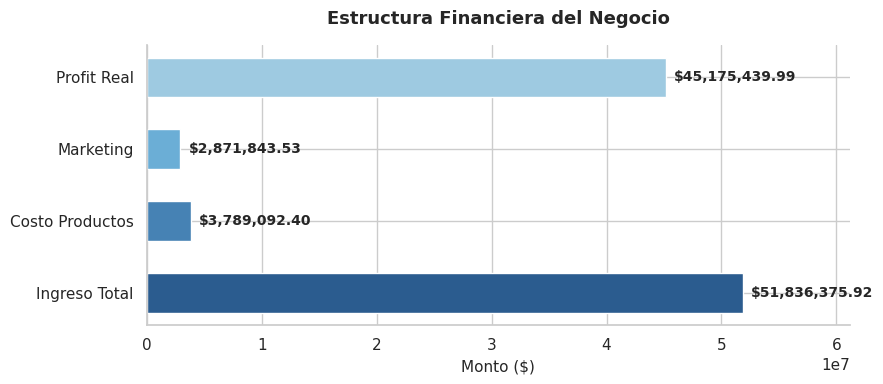

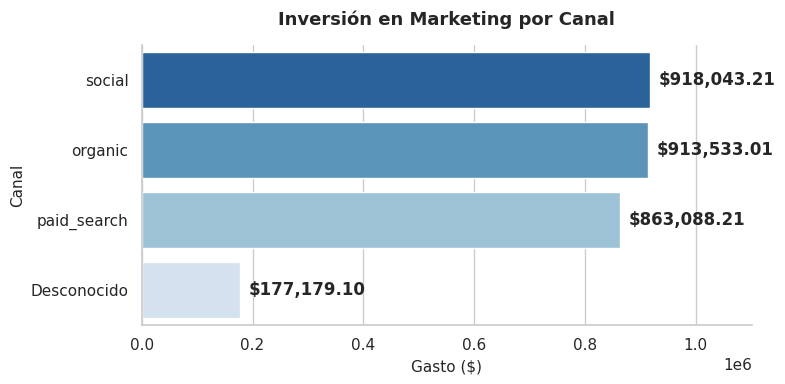

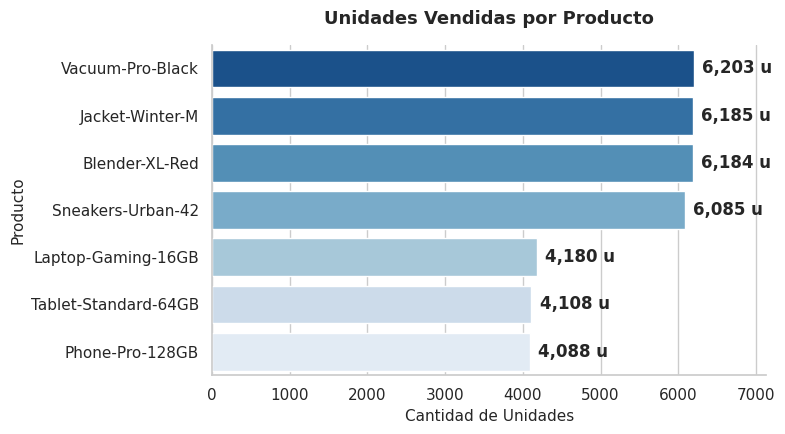

In [52]:

# Configuración de estilo global
sns.set_theme(style="whitegrid")


# GRAFICO PARTE 1: RENTABILIDAD DEL NEGOCIO

profit_real = ingreso_total - costo_total - inversion_marketing

fig, ax = plt.subplots(figsize=(9, 4))

metricas = ['Ingreso Total', 'Costo Productos', 'Marketing', 'Profit Real']
valores = [ingreso_total, costo_total, inversion_marketing, profit_real]

# Paleta en degradado de azul (de oscuro a claro)
colores_azules = ['#2b5c8f', '#4682b4', '#6baed6', '#9ecae1']

bars = ax.barh(metricas, valores, color=colores_azules, height=0.55)

# Agregar etiquetas de valor en cada barra
for bar in bars:
    width = bar.get_width()
    ax.annotate(f'${width:,.2f}',
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(6, 0),
                textcoords="offset points",
                ha='left', va='center', fontweight='bold', fontsize=10)

plt.title('Estructura Financiera del Negocio', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Monto ($)', fontsize=11)
ax.set_xlim(0, ingreso_total * 1.18)
sns.despine()
plt.tight_layout()
plt.show()


# GRAFICOS PARTE 2: COMPORTAMIENTO DE VENTAS


# 1. Gasto en Marketing por Canal (Paleta Blues_r)
plt.figure(figsize=(8, 4))
df_canal = gasto_por_canal.reset_index().sort_values(by='gasto', ascending=False)

ax1 = sns.barplot(data=df_canal, x='gasto', y='canal', palette='Blues_r')

plt.title('Inversión en Marketing por Canal', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Gasto ($)', fontsize=11)
plt.ylabel('Canal', fontsize=11)

for p in ax1.patches:
    ax1.annotate(f'${p.get_width():,.2f}', 
                 (p.get_width(), p.get_y() + p.get_height() / 2.), 
                 ha='left', va='center', xytext=(6, 0), textcoords='offset points', fontweight='bold')

ax1.set_xlim(0, df_canal['gasto'].max() * 1.2)
sns.despine()
plt.tight_layout()
plt.show()

# 2. Top Productos Más Vendidos (Paleta Blues_r)
plt.figure(figsize=(8, 4.5))
df_prod = orders_catalog.groupby('nombre_producto')['cantidad_winsor'].sum().reset_index().sort_values(by='cantidad_winsor', ascending=False)

ax2 = sns.barplot(data=df_prod, x='cantidad_winsor', y='nombre_producto', palette='Blues_r')

plt.title('Unidades Vendidas por Producto', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Cantidad de Unidades', fontsize=11)
plt.ylabel('Producto', fontsize=11)

for p in ax2.patches:
    ax2.annotate(f'{int(p.get_width()):,} u', 
                 (p.get_width(), p.get_y() + p.get_height() / 2.), 
                 ha='left', va='center', xytext=(6, 0), textcoords='offset points', fontweight='bold')

ax2.set_xlim(0, df_prod['cantidad_winsor'].max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

---

Conclusión: Incluso descontando la inversión en marketing, el negocio genera más de $45.17 millones de ganancia limpia, demostrando un modelo comercial sumamente sólido y altamente rentable.

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [121]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [122]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [123]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''
SELECT
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios
FROM events
GROUP BY nombre_evento
ORDER BY usuarios DESC;

'''

totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento,usuarios
0,first_visit,7796
1,add_to_cart,7634
2,select_item,7582
3,begin_checkout,7208
4,add_payment_info,6250
5,purchase,6240


In [124]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''
WITH cte_first_visit AS (
    SELECT DISTINCT id_usuario
    FROM events 
    WHERE nombre_evento = 'first_visit'
),

cte_add_to_cart AS (
    SELECT DISTINCT id_usuario
    FROM events 
    WHERE nombre_evento = 'add_to_cart'
),

cte_select_item AS (
    SELECT DISTINCT id_usuario
    FROM events 
    WHERE nombre_evento = 'select_item'

),
cte_begin_checkout AS (
    SELECT DISTINCT id_usuario
    FROM events 
    WHERE nombre_evento = 'begin_checkout'
),
cte_add_payment_info AS (
    SELECT DISTINCT id_usuario
    FROM events 
    WHERE nombre_evento = 'add_payment_info'
),
cte_purchase AS (
    SELECT DISTINCT id_usuario
    FROM events 
    WHERE nombre_evento = 'purchase'
)
SELECT
    (SELECT COUNT(*) FROM cte_first_visit) AS first_visit_users,
    (SELECT COUNT(*) FROM cte_add_to_cart) AS add_to_cart_users,
    (SELECT COUNT(*) FROM cte_select_item) AS select_item_users,
    (SELECT COUNT(*) FROM cte_begin_checkout) AS begin_checkout_users,
    (SELECT COUNT(*) FROM cte_add_payment_info) AS add_payment_info_users,
    (SELECT COUNT(*) FROM cte_purchase) AS purchase_users,

    --Calculo de drop off entre first_visit y add_to_cart
        ((SELECT COUNT(*) FROM cte_first_visit) - (SELECT COUNT(*) FROM cte_add_to_cart)) * 100.0
        / NULLIF((SELECT COUNT(*) FROM cte_first_visit), 0) AS dropoff_after_first_visit_pct,


    --Calculo de drop off entre add_to_cart y select_item
        ((SELECT COUNT(*) FROM cte_add_to_cart) - (SELECT COUNT(*) FROM cte_select_item)) * 100.0
        / NULLIF((SELECT COUNT(*) FROM cte_add_to_cart), 0) AS dropoff_after_add_to_cart_pct,


    --Calculo de drop off entre select_item y begin_checkout
        ((SELECT COUNT(*) FROM cte_select_item) - (SELECT COUNT(*) FROM cte_begin_checkout)) * 100.0
        / NULLIF((SELECT COUNT(*) FROM cte_select_item), 0) AS dropoff_after_select_item_pct,

    --Calculo de drop off entre begin_checkout y add_payment_info
        ((SELECT COUNT(*) FROM cte_begin_checkout) - (SELECT COUNT(*) FROM cte_add_payment_info)) * 100.0
        / NULLIF((SELECT COUNT(*) FROM cte_begin_checkout), 0) AS dropoff_after_begin_checkout_pct,

    --Calculo de drop off entre add_payment_info y purchase
        ((SELECT COUNT(*) FROM cte_add_payment_info) - (SELECT COUNT(*) FROM cte_purchase)) * 100.0
        / NULLIF((SELECT COUNT(*) FROM cte_add_payment_info), 0) AS dropoff_after_add_payment_info_pct;
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion

,first_visit_users,add_to_cart_users,select_item_users,begin_checkout_users,add_payment_info_users,purchase_users,dropoff_after_first_visit_pct,dropoff_after_add_to_cart_pct,dropoff_after_select_item_pct,dropoff_after_begin_checkout_pct,dropoff_after_add_payment_info_pct
0,7796,7634,7582,7208,6250,6240,2.077989,0.681163,4.932735,13.290788,0.16


---

Los usuarios dejan de comprar principalmente en la etapa de iniciar el pago (dropoff_after_begin_checkout_pct), representando el punto de fuga (drop-off) más crítico de todo el embudo con un 13.29%.

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users` 
- `user_activity` 

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [125]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [126]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [127]:
# Retención por cohortes
# ======================

query_cohort_retention_final = '''

/* 1. Identificar la cohorte de cada usuario */
WITH cohortes AS (
    SELECT 
        id_usuario,
        DATE_TRUNC('month', fecha_registro::date) AS cohorte_mes,
        fecha_registro::date AS fecha_registro
    FROM users
),

/* 2. Calcular el total inicial y los usuarios activos por semana */
retencion AS (
    SELECT
        c.cohorte_mes,
        COUNT(DISTINCT c.id_usuario) AS clientes_iniciales,
        
        -- Cálculo de semanas transcurridas: (fecha_actividad - fecha_registro) / 7
        COUNT(DISTINCT CASE 
            WHEN ((a.fecha_actividad::date - c.fecha_registro) / 7) = 1 AND a.activo = 1 
            THEN a.id_usuario 
        END) AS retenido_w1,
        
        COUNT(DISTINCT CASE 
            WHEN ((a.fecha_actividad::date - c.fecha_registro) / 7) = 2 AND a.activo = 1 
            THEN a.id_usuario 
        END) AS retenido_w2,
        
        COUNT(DISTINCT CASE 
            WHEN ((a.fecha_actividad::date - c.fecha_registro) / 7) = 3 AND a.activo = 1 
            THEN a.id_usuario 
        END) AS retenido_w3

    FROM cohortes c
    LEFT JOIN user_activity a ON c.id_usuario = a.id_usuario
    GROUP BY c.cohorte_mes
)

/* 3. Calcular la tasa de retención final en porcentaje */
SELECT
    TO_CHAR(cohorte_mes, 'YYYY-MM') AS cohorte,
    clientes_iniciales,
    ROUND(100.0 * retenido_w1::numeric / NULLIF(clientes_iniciales, 0), 2) AS semana_1,
    ROUND(100.0 * retenido_w2::numeric / NULLIF(clientes_iniciales, 0), 2) AS semana_2,
    ROUND(100.0 * retenido_w3::numeric / NULLIF(clientes_iniciales, 0), 2) AS semana_3
FROM retencion
ORDER BY cohorte_mes;

'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,cohorte,clientes_iniciales,semana_1,semana_2,semana_3
0,2025-01,1627,42.84,41.06,40.32
1,2025-02,1444,42.31,42.17,43.98
2,2025-03,1636,41.38,43.09,42.18
3,2025-04,1606,42.34,43.40,41.28
4,2025-05,1687,41.20,40.07,41.85


---

Cerca del $58\%$ de los nuevos usuarios abandonan la plataforma tras la primera interacción, pero el $42\%$ restante se convierte en una base recurrente altamente estable, manteniendo su actividad constante al menos hasta la tercera semana.

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado** 
4. **Interpretar el resultado**  

---
Hipótesis estadística
   - **H₀ (Hipótesis nula):** No hay diferencia en la tasa de conversión entre el grupo de control y el grupo de tratamiento 
   - **H₁ (Hipótesis alternativa):** Sí hay diferencia en la tasa de conversión entre el grupo de control y el grupo de tratamiento 
   
**Test estadístico:** Chi cuadrado, para analizar si esxiste relación entre variables categoricas 
**Nivel de significancia alpha:** 5%

In [128]:
# cargar archivo

experiment = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')


In [129]:
experiment.head()

,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12


In [130]:
experiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_usuario       10000 non-null  object 
 1   variante         10000 non-null  object 
 2   convirtio        10000 non-null  int64  
 3   dispositivo      10000 non-null  object 
 4   pais             10000 non-null  object 
 5   duracion_sesion  10000 non-null  float64
 6   timestamp        10000 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 547.0+ KB


In [131]:
# Conteo de usuarios

experiment[['variante', 'convirtio']].value_counts()

variante     convirtio
tratamiento  0            4215
control      0            4186
tratamiento  1             820
control      1             779
dtype: int64

In [132]:

# Tabla de contingencia

tabla = pd.crosstab(experiment["variante"], experiment['convirtio'])

tabla

convirtio,0,1
variante,,
control,4186,779
tratamiento,4215,820


In [133]:

# Tabla de contingencia normalizada

pd.crosstab(experiment["variante"], experiment['convirtio'], normalize='index')



convirtio,0,1
variante,,
control,0.843102,0.156898
tratamiento,0.837140,0.162860


In [134]:
# Prueba chi cuadrado

chi2_stat, p_value, dof, expected = chi2_contingency(tabla)

print(f"Estadistico chi-cuadrado: {chi2_stat: .3f}")
print(f"Valor P: {p_value: .3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)

Estadistico chi-cuadrado:  0.618
Valor P:  0.432
Grados de libertad: 1

Frecuencias esperadas:
[[4171.0965  793.9035]
 [4229.9035  805.0965]]


In [135]:
# Hipotesis

alpha = 0.05
if p_value < alpha:
    print("Rechazamos la hipotesis nula: hay evidencia de asociación entre variables")
else:
    print("No rechazamos la hipotesis nula: no hay evidencia suficiente de asociación entre variables")

No rechazamos la hipotesis nula: no hay evidencia suficiente de asociación entre variables


**Conclusión**

Con base en un chi-square test de independencia, no encontramos evidencia estadística de que la conversión está asociada a la modificación en la UI del checkout.

Este resultado se basa en una muestra de usuarios y no implica causalidad directa ni evalúa si esta diferencia justifica decisiones diferenciadas desde una perspectiva de negocio.”

---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión. 

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

---

## 🚀 Entrega Final

Comparte el acceso a tu Dashboard para revisión.   
Puedes entregar el Dashboard utilizando **Power BI o Tableau**.

Incluye **uno de los siguientes**:

- 🔗 Link público del dashboard publicado en **Power BI Service o Tableau Public / Tableau Cloud**
- 🔗 Link de **Google Drive o OneDrive** con el archivo del proyecto (`.pbix`) y los 3 csvs limpios.


### 📎 Enlace del Dashboard


https://drive.google.com/drive/folders/16Y2bXVTQEEv6NI2lzUM5qE0i_WNYZG4n?usp=sharing


# link de google drive